In [10]:
import pandas as pd
import pandas_ta as ta

df = pd.read_csv("../../data/MSFT.USUSD_Candlestick_1_Hour_ASK_05.10.2022-05.10.2024.csv")
df=df[0:5000]
df=df[df['Volume']!=0]
df["Gmt time"]=df["Gmt time"].str.replace(".000","")
df['Gmt time']=pd.to_datetime(df['Gmt time'],format='%d.%m.%Y %H:%M:%S')

## Take the rolling atr so the yaxis doesn't shake too much 
df["atr"] = ta.atr(high=df.High, low=df.Low, close=df.Close)
df["atr"] = df.atr.rolling(window=30).mean()

df.reset_index(drop=True, inplace=True)

df

,Gmt time,Open,High,Low,Close,Volume,atr
0,2022-10-05 13:00:00,246.203,247.274,245.293,246.183,16.2972,NaN
1,2022-10-05 14:00:00,246.173,246.174,244.134,244.384,37.5060,NaN
2,2022-10-05 15:00:00,244.383,245.954,244.284,245.663,33.1452,NaN
3,2022-10-05 16:00:00,245.644,248.304,245.013,247.674,31.7760,NaN
4,2022-10-05 17:00:00,247.674,248.973,247.563,247.613,26.4408,NaN
...,...,...,...,...,...,...,...
984,2023-04-28 15:00:00,305.623,306.063,304.733,305.683,22.6356,2.463945
985,2023-04-28 16:00:00,305.693,306.654,304.133,305.023,17.4108,2.489645
986,2023-04-28 17:00:00,305.024,305.754,304.324,305.514,16.3488,2.504722
987,2023-04-28 18:00:00,305.514,306.174,305.133,305.914,16.7472,2.518056


In [3]:
%matplotlib inline

import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.signal import find_peaks
pd.set_option('mode.chained_assignment', None)

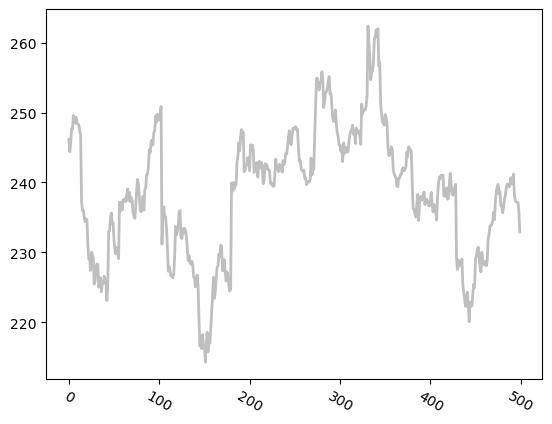

In [4]:
df2 = df.iloc[0:500]

fig, ax = plt.subplots()
plt.xticks(rotation=-30)
price, = ax.plot(df2.index, df2.Close, c='grey', lw=2, alpha=0.5, zorder=5)

plt.show()

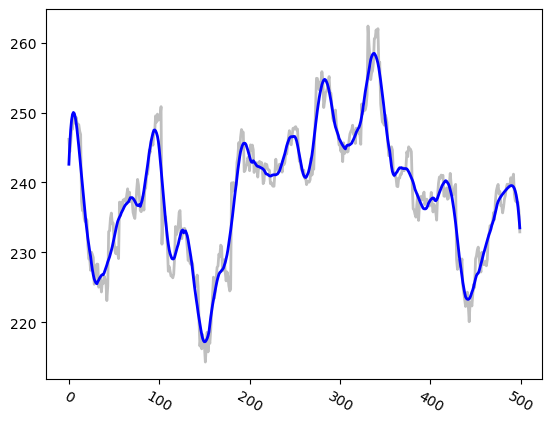

In [5]:
df2 = df.iloc[0:500]

df2["close_smooth"] = savgol_filter(df2.Close, 49, 5)

fig, ax = plt.subplots()
plt.xticks(rotation=-30)
price, = ax.plot(df2.index, df2.Close, c='grey', lw=2, alpha=0.5, zorder=5)
price_smooth, = ax.plot(df2.index, df2.close_smooth, c='b', lw=2, zorder=5)

plt.show()

[ 91 196 235 306 445]
[ 62 143 218 270 385 466]


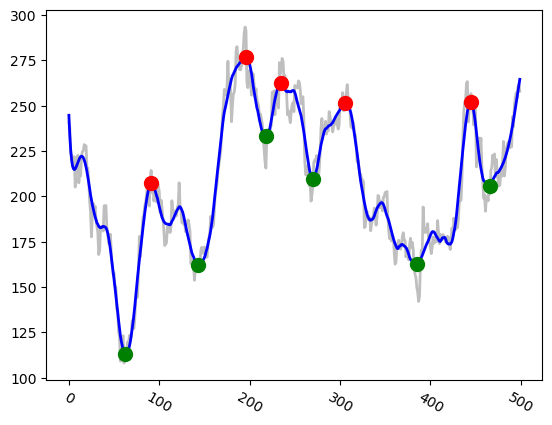

In [9]:
df2 = df.iloc[0:500]

df2["close_smooth"] = savgol_filter(df2.Close, 49, 5)

fig, ax = plt.subplots()
plt.xticks(rotation=-30)
price, = ax.plot(df2.index, df2.Close, c='grey', lw=2, alpha=0.5, zorder=5)
price_smooth, = ax.plot(df2.index, df2.close_smooth, c='b', lw=2, zorder=5)

atr = df2.atr.iloc[-1] # all the first atrs are NaN

peaks_idx, _ = find_peaks(df2.close_smooth, distance = 15, width = 3, prominence=atr)

print(peaks_idx)

troughs_idx, _ = find_peaks(-1*df2.close_smooth, distance = 15, width = 3, prominence=atr)

print(troughs_idx)

peaks, = ax.plot(df2.index[peaks_idx], df2.close_smooth.iloc[peaks_idx], \
                 c="r", linestyle='None', markersize = 10.0, marker = "o", zorder=10)

troughs, = ax.plot(df2.index[troughs_idx], df2.close_smooth.iloc[troughs_idx], \
                   c="g", linestyle='None', markersize = 10.0, marker = "o", zorder=10)

plt.show()

0


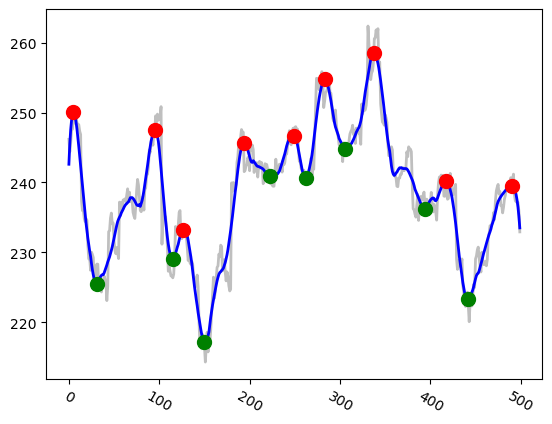

In [6]:
df2 = df.iloc[0:500]

df2["close_smooth"] = savgol_filter(df2.Close, 49, 5)

fig, ax = plt.subplots()
plt.xticks(rotation=-30)
plt.xticks(rotation=-30)
price, = ax.plot(df2.index, df2.Close, c='grey', lw=2, alpha=0.5, zorder=5)
price_smooth, = ax.plot(df2.index, df2.close_smooth, c='b', lw=2, zorder=5)

atr = df2.atr.iloc[-1] # all the first atrs are NaN

peaks_idx, _ = find_peaks(df2.close_smooth, distance = 15, width = 3, prominence=atr)

troughs_idx, _ = find_peaks(-1*df2.close_smooth, distance = 15,width = 3, prominence=atr)

peaks, = ax.plot(df2.index[peaks_idx], df2.close_smooth.iloc[peaks_idx], \
                 c="r", linestyle='None', markersize = 10.0, marker = "o", zorder=10)

troughs, = ax.plot(df2.index[troughs_idx], df2.close_smooth.iloc[troughs_idx], \
                   c="g", linestyle='None', markersize = 10.0, marker = "o", zorder=10)


up_run_length = 0
up_run = True
while up_run:
    if 2 + up_run_length > len(peaks_idx) or 2 + up_run_length > len(troughs_idx):
        break
        
    if df2.close_smooth.iloc[peaks_idx[-1 - up_run_length]] > df2.close_smooth.iloc[peaks_idx[-2 - up_run_length]] and \
       df2.close_smooth.iloc[troughs_idx[-1 - up_run_length]] > df2.close_smooth.iloc[troughs_idx[-2 - up_run_length]]:
        up_run_length += 1
    else:
        up_run = False    
          

if up_run_length > 0:
    ax.set_facecolor((150/255, 255/255, 159/255, 0.3))  
else:
    ax.set_facecolor("white")
        
print(up_run_length)

plt.show()